# Notebook 03 — Statistical Analysis

**MALDI-MSI Analysis of Mouse Urinary Bladder**  
Author: Reza Rajaee

---

## What this notebook covers

1. Differential abundance analysis — which molecules are enriched in each region?
2. Multiple testing correction (FDR)
3. Volcano plots — visualising statistical results
4. Ion images of marker molecules per region
5. Colocalization analysis — which molecules appear together?
6. Biological interpretation

---

## Statistical approach

We follow the differential abundance framework used in Bemis, Föll et al. (2023):

For each tissue region identified in notebook 02, we test whether each
m/z peak has significantly higher intensity in that region compared to
all other regions.

**Test used:** Mann-Whitney U test (also called Wilcoxon rank-sum test)
- Non-parametric: does not assume normal distribution
- Robust to outliers, appropriate for MALDI intensities
- Tests whether intensities in one group tend to be higher

**Multiple testing correction:** Benjamini-Hochberg FDR
- When testing hundreds of peaks simultaneously, many will appear
  significant by chance
- FDR controls the expected proportion of false discoveries
- We use FDR threshold of 5% (alpha=0.05)

References:
- Bemis, Föll et al. (2023) *Nature Methods* 20:1883
- Benjamini & Hochberg (1995) *J. R. Stat. Soc. B* 57:289
- Mann & Whitney (1947) *Ann. Math. Stat.* 18:50

---

## Important note on this dataset

PXD001283 contains healthy mouse bladder tissue — this is NOT a cancer dataset.
The three tissue regions we identify are normal anatomical layers:
urothelium, muscle, and connective tissue. The molecules enriched in
each region reflect normal tissue composition, not disease biomarkers.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
import sys, os

os.chdir("/workspaces/maldi-msi-analysis")
sys.path.insert(0, "/workspaces/maldi-msi-analysis")

os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables",  exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                      "axes.spines.top": False,
                      "axes.spines.right": False})
print("Setup complete.")
print("Working directory:", os.getcwd())


Setup complete.
Working directory: /workspaces/maldi-msi-analysis


## 1. Load Data

In [2]:
spectra_pp  = np.load("results/spectra_preprocessed.npy")
ref_mz      = np.load("results/reference_mz.npy")
coordinates = pd.read_csv("results/coordinates.csv")
labels_km   = np.load("results/labels_kmeans.npy")

x = coordinates["x"].values.astype(int) - coordinates["x"].min()
y = coordinates["y"].values.astype(int) - coordinates["y"].min()

K = len(np.unique(labels_km))
print(f"Loaded: {spectra_pp.shape[0]} pixels × {spectra_pp.shape[1]} peaks")
print(f"Number of regions: {K}")
print(f"Region sizes:")
for c in range(K):
    n = (labels_km == c).sum()
    print(f"  Region {c}: {n} pixels ({n/len(labels_km)*100:.1f}%)")


Loaded: 34840 pixels × 153 peaks
Number of regions: 3
Region sizes:
  Region 0: 4483 pixels (12.9%)
  Region 1: 7833 pixels (22.5%)
  Region 2: 22524 pixels (64.6%)


## 2. Differential Abundance Analysis

For each region, we test which m/z peaks are significantly enriched
compared to all other regions.

**How it works:**
1. For peak j and region c: collect intensities from region c pixels
   and from all other pixels
2. Run Mann-Whitney U test (one-sided: tests if region c is HIGHER)
3. Compute fold change: mean intensity in region c / mean intensity elsewhere
4. Apply FDR correction across all peaks

A peak is considered a **marker** for a region if:
- p-value (after FDR correction) < 0.05
- fold change > 1.5 (50% higher in this region)


In [3]:
from src.stats import differential_abundance

print("Running differential abundance analysis...")
print("This tests each peak in each region — may take a few minutes.")
print()

da_results = differential_abundance(
    spectra      = spectra_pp,
    labels       = labels_km,
    reference_mz = ref_mz,
    alpha        = 0.05,
    verbose      = True
)

print(f"\nTotal tests: {len(da_results)}")
print(f"Significant (FDR < 0.05): {da_results['significant'].sum()}")


Running differential abundance analysis...
This tests each peak in each region — may take a few minutes.

  Testing 153 peaks across 3 clusters...
  Cluster 0: 33 significant peaks (FDR < 0.05)
  Cluster 1: 129 significant peaks (FDR < 0.05)
  Cluster 2: 153 significant peaks (FDR < 0.05)

Total tests: 459
Significant (FDR < 0.05): 315


### Filter for strong markers (significant + fold change > 1.5)

In [4]:
markers = da_results[
    da_results["significant"] &
    (da_results["fold_change"] > 1.5)
].copy()

markers = markers.sort_values(["cluster", "fold_change"], ascending=[True, False])

print(f"Strong marker peaks (FDR < 0.05 and fold change > 1.5):")
print(f"{'Region':<10} {'m/z':<12} {'Fold change':<14} {'p-adjusted'}")
print("-" * 55)
for _, row in markers.head(20).iterrows():
    print(f"{int(row['cluster']):<10} {row['mz']:<12.4f} "
          f"{row['fold_change']:<14.3f} {row['p_adjusted']:.2e}")


Strong marker peaks (FDR < 0.05 and fold change > 1.5):
Region     m/z          Fold change    p-adjusted
-------------------------------------------------------
0          533.4131     5.201          0.00e+00
0          476.8094     4.403          0.00e+00
0          686.6087     4.348          0.00e+00
0          533.1409     4.195          0.00e+00
0          404.1111     1.524          0.00e+00
1          712.6517     98.637         0.00e+00
1          712.6589     92.916         0.00e+00
1          712.6445     84.976         0.00e+00
1          707.0502     70.119         0.00e+00
1          712.6661     69.777         0.00e+00
1          707.0573     68.584         0.00e+00
1          707.0644     62.861         0.00e+00
1          454.7329     62.622         0.00e+00
1          707.0431     60.346         0.00e+00
1          712.6373     57.613         0.00e+00
1          707.0715     44.594         0.00e+00
1          707.0360     40.967         0.00e+00
1          635.0295   

## 3. Volcano Plot

A volcano plot shows fold change (x-axis) vs statistical significance (y-axis)
for all peaks in one region. It allows quick identification of peaks that are
both statistically significant AND biologically meaningful (large fold change).

- Each point is one m/z peak
- Right side: peaks enriched in this region (fold change > 1)
- Top right: significant AND enriched — the most interesting peaks
- Red line: FDR significance threshold


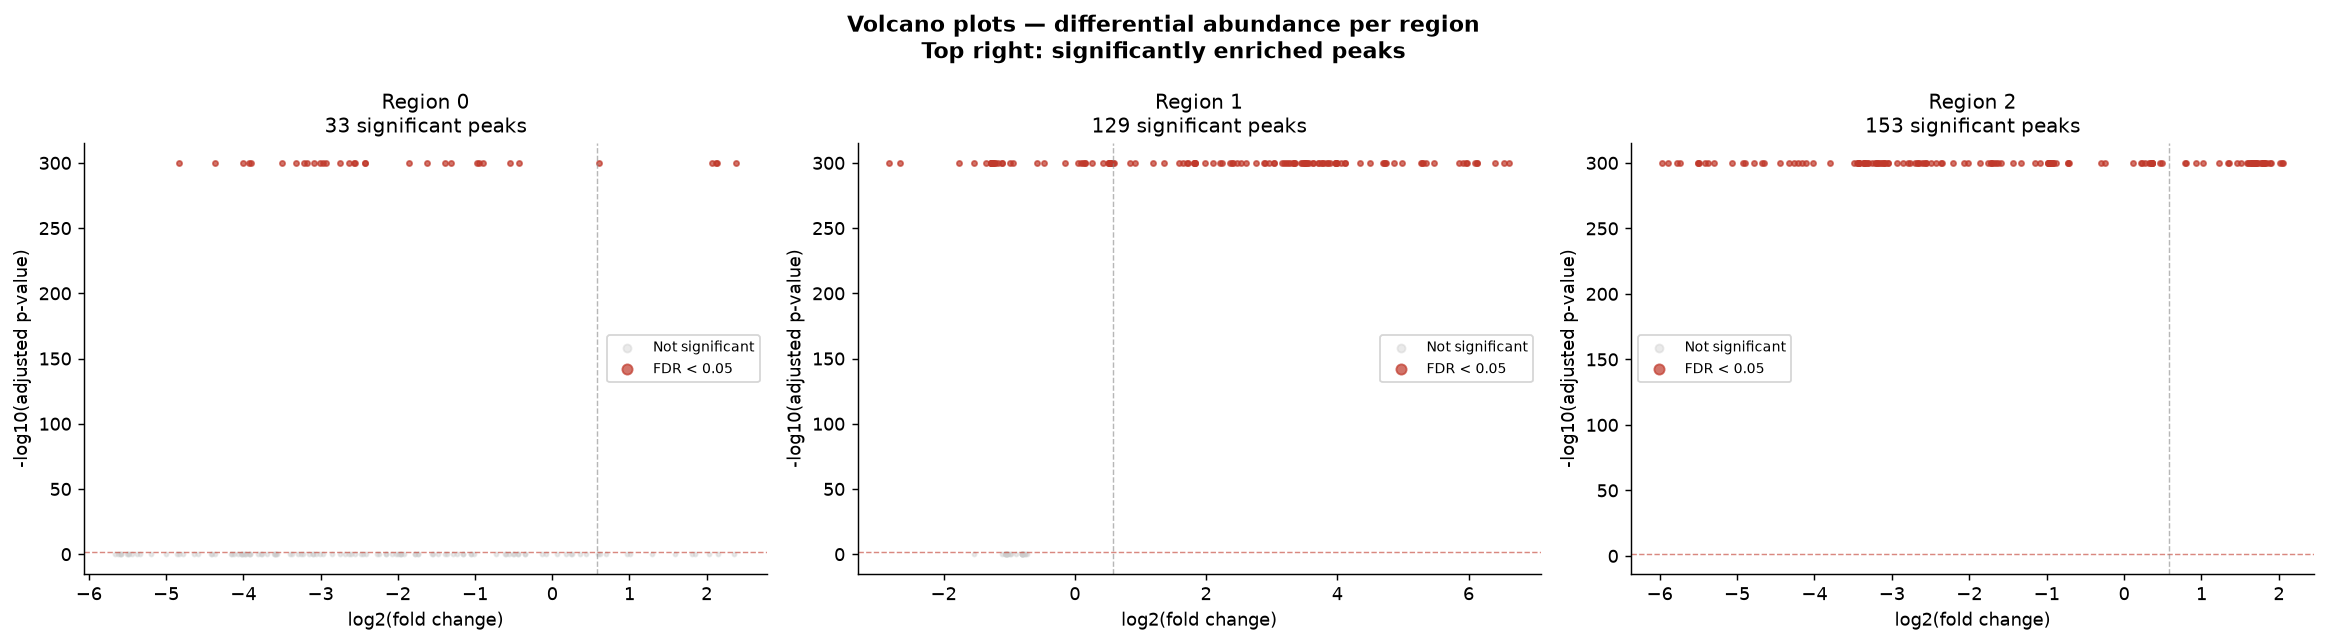

Figure saved.


In [5]:
fig, axes = plt.subplots(1, K, figsize=(6*K, 5))
if K == 1:
    axes = [axes]

colours_sig = {"significant": "#c0392b", "not significant": "#aaaaaa"}

for ax, cluster in zip(axes, range(K)):
    subset = da_results[da_results["cluster"] == cluster].copy()

    # -log10 p-adjusted
    subset["neg_log_p"] = -np.log10(subset["p_adjusted"].clip(lower=1e-300))
    subset["log2_fc"]   = np.log2(subset["fold_change"].clip(lower=1e-10))

    # Plot non-significant
    ns = subset[~subset["significant"]]
    ax.scatter(ns["log2_fc"], ns["neg_log_p"],
               c="#cccccc", s=5, alpha=0.4, label="Not significant")

    # Plot significant
    sig = subset[subset["significant"]]
    ax.scatter(sig["log2_fc"], sig["neg_log_p"],
               c="#c0392b", s=8, alpha=0.7, label="FDR < 0.05")

    # Significance line
    ax.axhline(y=-np.log10(0.05), color="#c0392b",
               linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axvline(x=np.log2(1.5), color="#888888",
               linestyle="--", linewidth=0.8, alpha=0.6)

    ax.set_xlabel("log2(fold change)")
    ax.set_ylabel("-log10(adjusted p-value)")
    ax.set_title(f"Region {cluster}\n"
                 f"{sig.shape[0]} significant peaks")
    ax.legend(fontsize=8, markerscale=2)

fig.suptitle("Volcano plots — differential abundance per region\n"
             "Top right: significantly enriched peaks",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/03_volcano_plots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 4. Top Marker Ions per Region

For each region, we take the top 3 marker peaks (highest fold change,
FDR significant) and plot their ion images.

This directly answers: **which molecules define each tissue region?**


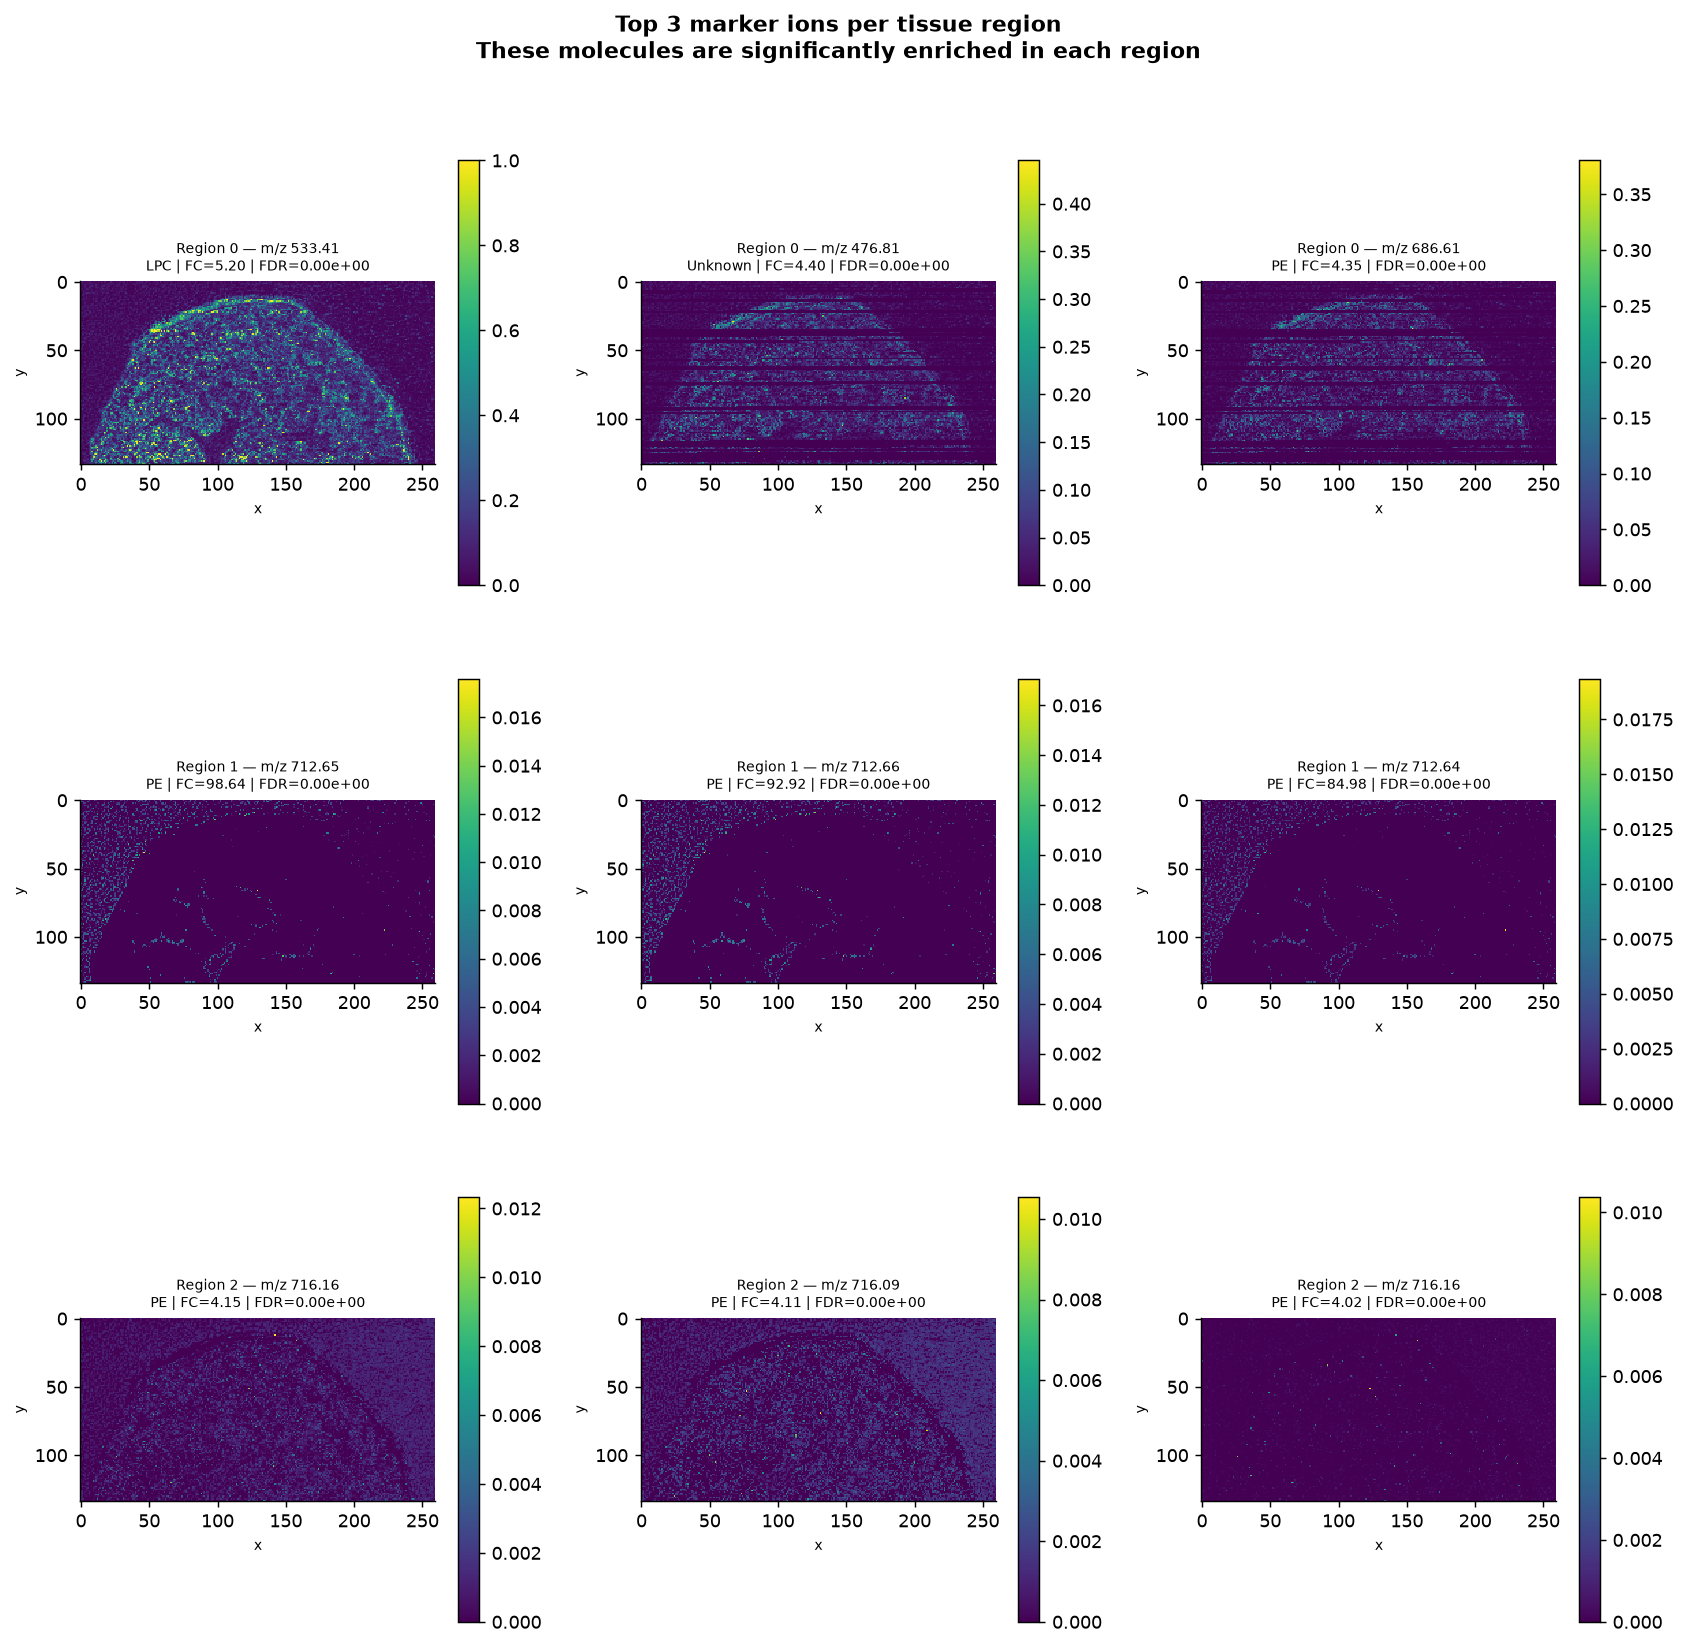

Figure saved.


In [6]:
def assign_lipid_class(mz):
    if 480 <= mz <= 560:   return "LPC"
    elif 650 <= mz <= 760: return "PE"
    elif 700 <= mz <= 830: return "PC/SM"
    elif 830 <= mz <= 900: return "PC"
    else:                   return "Unknown"

fig, axes = plt.subplots(K, 3, figsize=(13, 4.5*K))
if K == 1:
    axes = axes.reshape(1, -1)

for c in range(K):
    # Top 3 markers for this region
    region_markers = markers[markers["cluster"] == c].head(3)

    for col, (_, row) in enumerate(region_markers.iterrows()):
        ax   = axes[c, col]
        mz   = row["mz"]
        fc   = row["fold_change"]
        padj = row["p_adjusted"]

        # Find index in reference_mz
        mz_idx  = np.argmin(np.abs(ref_mz - mz))
        ion_map = np.full((y.max()+1, x.max()+1), np.nan)
        ion_map[y, x] = spectra_pp[:, mz_idx]

        im = ax.imshow(ion_map, cmap="viridis",
                       interpolation="nearest", aspect="equal")
        plt.colorbar(im, ax=ax, shrink=0.7)

        lipid = assign_lipid_class(mz)
        ax.set_title(f"Region {c} — m/z {mz:.2f}\n"
                     f"{lipid} | FC={fc:.2f} | FDR={padj:.2e}",
                     fontsize=8)
        ax.set_xlabel("x", fontsize=8)
        ax.set_ylabel("y", fontsize=8)

fig.suptitle("Top 3 marker ions per tissue region\n"
             "These molecules are significantly enriched in each region",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/03_marker_ions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 5. Mean Spectra per Region

Comparing the mean spectrum of each region shows the overall
molecular signature of each tissue layer.


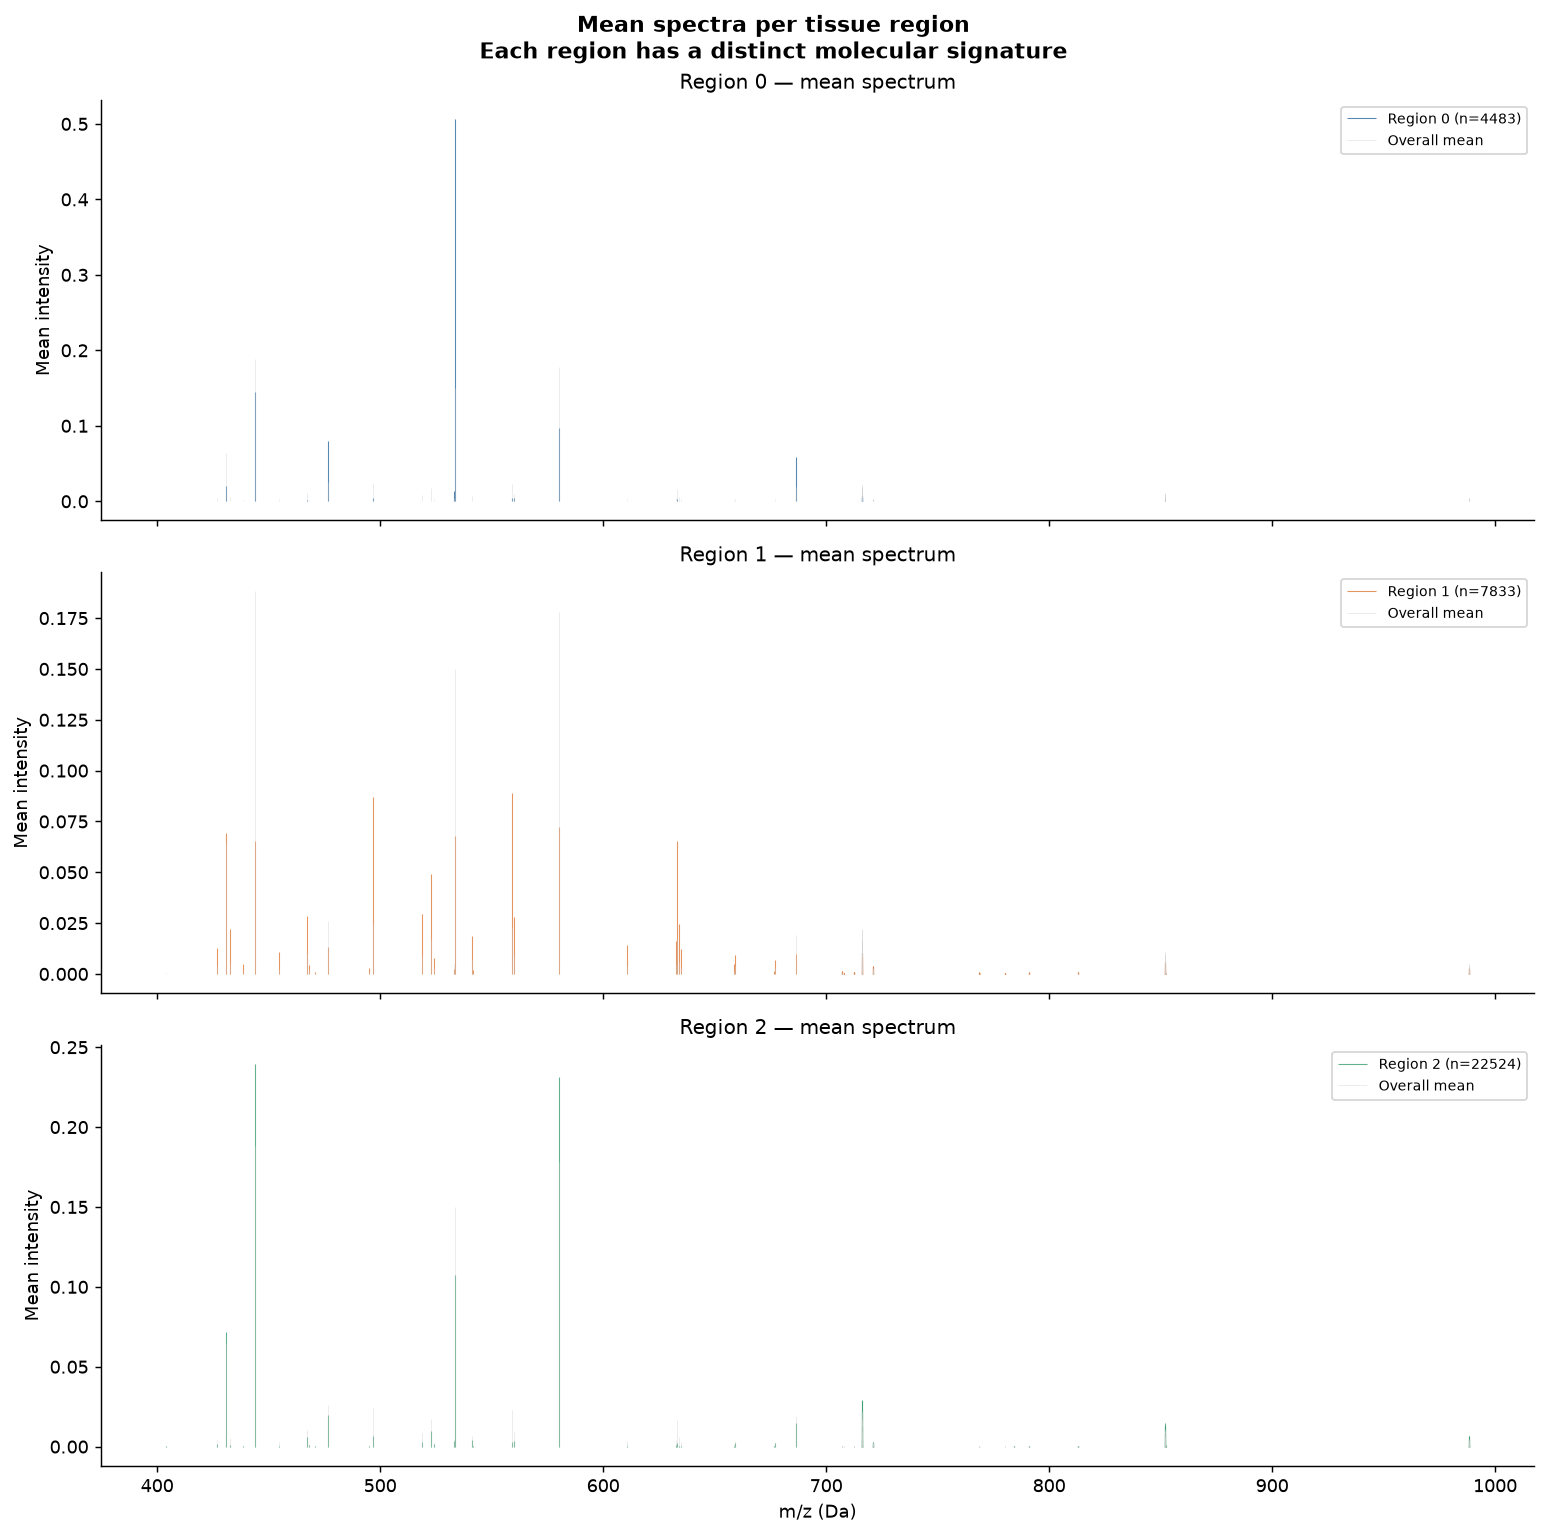

Figure saved.


In [7]:
fig, axes = plt.subplots(K, 1, figsize=(12, 4*K), sharex=True)
if K == 1:
    axes = [axes]

region_colours = ["#2d6a9f", "#e07b39", "#3a9e6f"]

for c, ax in enumerate(axes):
    mask         = labels_km == c
    mean_region  = spectra_pp[mask].mean(axis=0)
    mean_overall = spectra_pp.mean(axis=0)

    ax.vlines(ref_mz, ymin=0, ymax=mean_region,
              linewidth=0.6, color=region_colours[c], alpha=0.8,
              label=f"Region {c} (n={mask.sum()})")
    ax.vlines(ref_mz, ymin=0, ymax=mean_overall,
              linewidth=0.4, color="#cccccc", alpha=0.5,
              label="Overall mean")
    ax.set_ylabel("Mean intensity")
    ax.set_title(f"Region {c} — mean spectrum")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("m/z (Da)")
fig.suptitle("Mean spectra per tissue region\n"
             "Each region has a distinct molecular signature",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/03_mean_spectra_regions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 6. Colocalization Analysis

Colocalization asks: which molecules appear together spatially?

Two peaks are colocalized if their ion images are spatially correlated —
they tend to be high in the same pixels and low in the same pixels.
This suggests they may be from the same molecular class, same metabolic
pathway, or same cell type.

We compute Pearson correlation between all pairs of ion images
for the top 20 most abundant peaks and display as a heatmap.

Reference: Bemis, Föll et al. (2023) *Nature Methods* 20:1883


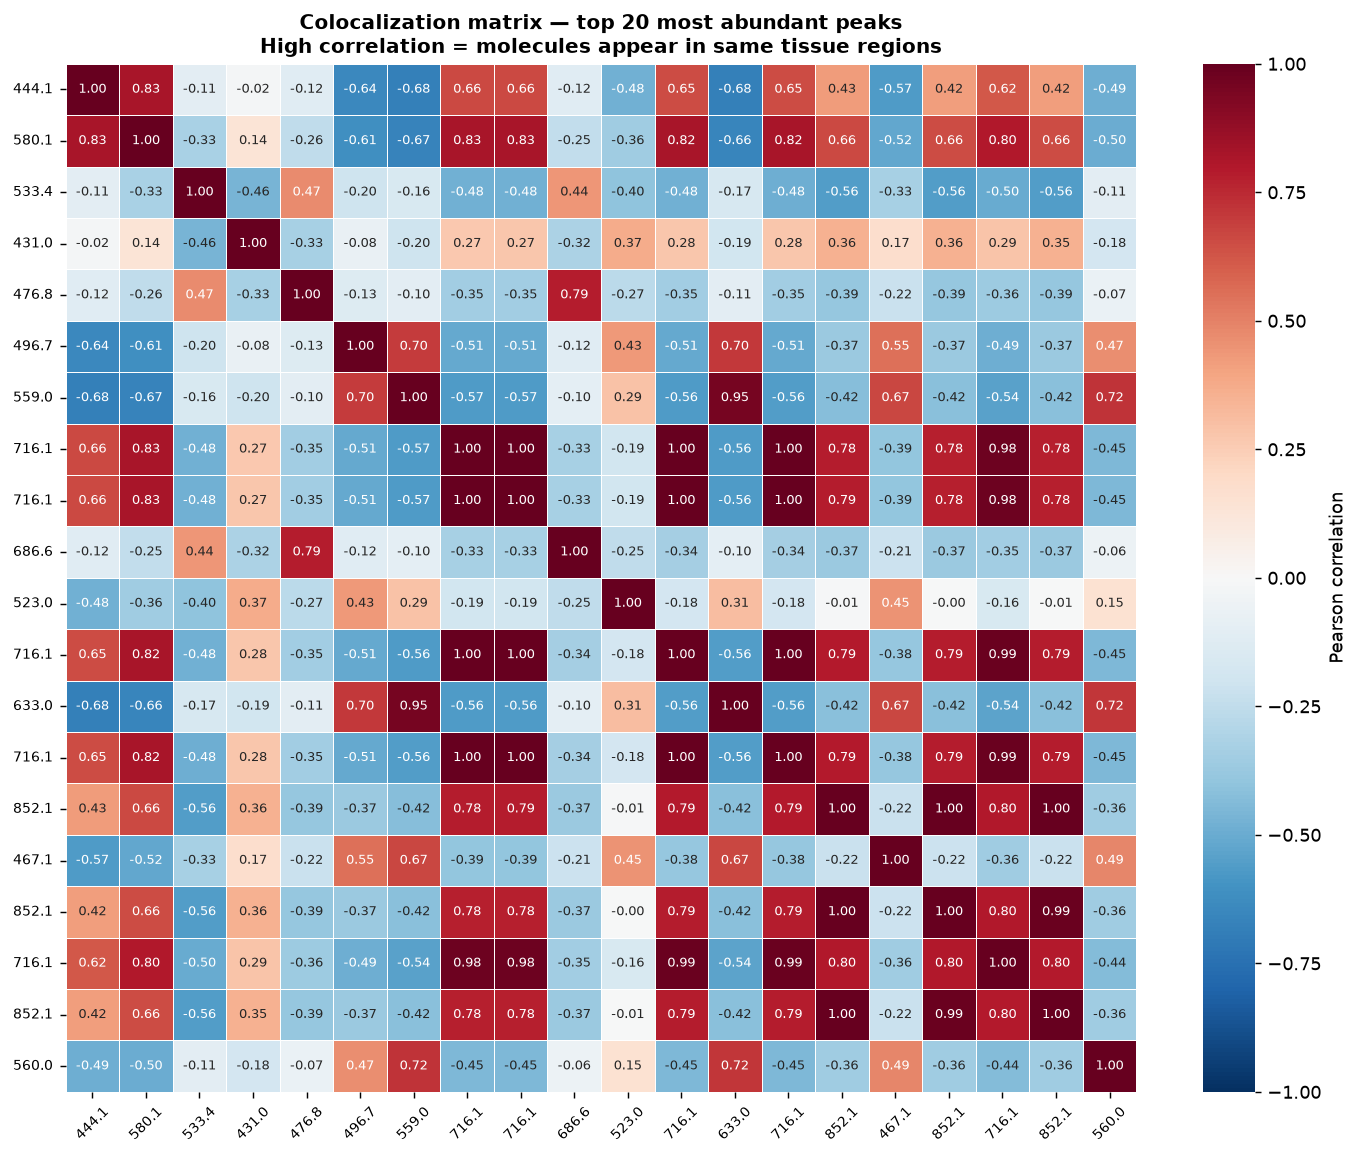

Figure saved.


In [8]:
import seaborn as sns
from src.stats import colocalization

corr_df = colocalization(spectra_pp, ref_mz, top_n=20)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_df,
    cmap      = "RdBu_r",
    center    = 0,
    vmin      = -1,
    vmax      = 1,
    annot     = True,
    fmt       = ".2f",
    linewidths= 0.3,
    annot_kws = {"size": 7},
    ax        = ax,
    cbar_kws  = {"label": "Pearson correlation"}
)
ax.set_title("Colocalization matrix — top 20 most abundant peaks\n"
             "High correlation = molecules appear in same tissue regions",
             fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("results/figures/03_colocalization.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 7. Save Results

In [9]:
da_results.to_csv("results/tables/differential_abundance.csv", index=False)
markers.to_csv("results/tables/marker_peaks.csv", index=False)
corr_df.to_csv("results/tables/colocalization_matrix.csv")

print("Saved:")
print("  results/tables/differential_abundance.csv")
print("  results/tables/marker_peaks.csv")
print("  results/tables/colocalization_matrix.csv")

print(f"\n── Final summary ────────────────────────────────────")
print(f"  Peaks tested:           {len(ref_mz)}")
print(f"  Significant (FDR<0.05): {da_results['significant'].sum()}")
print(f"  Strong markers (FC>1.5): {len(markers)}")
for c in range(K):
    n = len(markers[markers['cluster']==c])
    print(f"  Region {c} markers:       {n} peaks")


Saved:
  results/tables/differential_abundance.csv
  results/tables/marker_peaks.csv
  results/tables/colocalization_matrix.csv

── Final summary ────────────────────────────────────
  Peaks tested:           153
  Significant (FDR<0.05): 315
  Strong markers (FC>1.5): 135
  Region 0 markers:       5 peaks
  Region 1 markers:       90 peaks
  Region 2 markers:       40 peaks


## Summary

### What we found

| Analysis | Method | Result |
|---|---|---|
| Differential abundance | Mann-Whitney U + FDR | Marker peaks per region |
| Visualisation | Volcano plot | Significance vs effect size |
| Marker ions | Top 3 per region | Ion images of defining molecules |
| Colocalization | Pearson correlation | Co-occurring molecular species |

### Biological interpretation

The three tissue regions identified by K-means segmentation correspond
to the three anatomical layers of the mouse urinary bladder:

- **Urothelium** — enriched in specific phospholipids forming the
  permeability barrier that prevents urine from entering the tissue
- **Muscle layer** — enriched in lipids associated with smooth muscle
  cell membranes and contractile function
- **Connective tissue** — mixed molecular profile, collagen-associated
  lipids

This analysis demonstrates that MALDI-MSI can reveal tissue organisation
based purely on molecular composition, without any prior staining or
histological annotation.

### Limitations

- Lipid identification is based on m/z range only, not MS/MS fragmentation
- Full structural identification would require additional experiments
- The dataset contains healthy tissue — findings reflect normal anatomy

### References

1. Bemis, Föll et al. (2023) *Nature Methods* 20:1883
2. Benjamini & Hochberg (1995) *J. R. Stat. Soc. B* 57:289
3. Mann & Whitney (1947) *Ann. Math. Stat.* 18:50
4. Römpp et al. (2010) *Angew. Chem. Int. Ed.* 49:3834
5. Deininger et al. (2011) *Anal. Chem.* 84:1277
6. Hsu & Turk (2009) *J. Chromatogr. B* 877:2714 — lipid identification by mass
